# Online Retail Sales Analysis

Exploratory analysis of transactional data from a UK-based online retailer.

## Project objective

The objective is to analyze sales, customers, products, cancellations, and revenue trends and provide practical business recommendations.

In [88]:
from pathlib import Path
from google.colab import drive

drive.mount("/content/drive")

PROJECT_DIR = Path(
    "/content/drive/MyDrive/online-retail-analysis"
)

DATA_DIR = PROJECT_DIR / "data"
IMAGES_DIR = PROJECT_DIR / "images"

IMAGES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project directory: {PROJECT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directory: /content/drive/MyDrive/online-retail-analysis


In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

sns.set_theme(style="whitegrid")

In [90]:
data_path = DATA_DIR / "online_retail.xlsx"

df = pd.read_excel(data_path)

df.head()

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [91]:
print(f"Amount of rows: {df.shape[0]}")
print(f"Amount of columns: {df.shape[1]}")

df.info()

Amount of rows: 541909
Amount of columns: 8
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [92]:
df.describe(include="all")

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909.0,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900.0,4070,4223,NaN,NaN,NaN,NaN,38
top,573585.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114.0,2313,2369,NaN,NaN,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN


In [93]:
quality_report = pd.DataFrame({
    "data_type": df.dtypes.astype(str),
    "missing_values": df.isnull().sum(),
    "missing_percentage": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique(),
})

quality_report

,data_type,missing_values,missing_percentage,unique_values
InvoiceNo,object,0,0.00,25900
StockCode,object,0,0.00,4070
Description,object,1454,0.27,4223
Quantity,int64,0,0.00,722
InvoiceDate,datetime64[ns],0,0.00,23260
UnitPrice,float64,0,0.00,1630
CustomerID,float64,135080,24.93,4372
Country,object,0,0.00,38


In [94]:
print(f"Duplicated rows: {df.duplicated().sum():,}")
print(f"Rows with Quantity <= 0: {(df['Quantity'] <= 0).sum()}")
print(f"Rows with UnitPrice <= 0: {(df['UnitPrice'] <= 0).sum()}")

Duplicated rows: 5,268
Rows with Quantity <= 0: 10624
Rows with UnitPrice <= 0: 2517


## Data cleaning

The dataset contains missing values, duplicate rows, cancelled transactions, and records with non-positive quantities or prices. These records are examined and filtered before sales analysis.

In [95]:
sales_df = df.copy()

In [96]:
duplicate_count =  sales_df.duplicated().sum()

sales_df = sales_df.drop_duplicates()

print(f"Removed {duplicate_count:,} duplicated rows. New shape: {sales_df.shape}")

Removed 5,268 duplicated rows. New shape: (536641, 8)


In [97]:
sales_df["Cancelled"] = sales_df["InvoiceNo"].astype(str).str.startswith("C")

cancelled_rows = sales_df["Cancelled"].sum()

cancelled_invoices = sales_df.loc[
    sales_df["Cancelled"],
    "InvoiceNo"
].nunique()

print(f"Cancelled rows: {cancelled_rows:,}")
print(f"Cancelled invoices: {cancelled_invoices:,}")

Cancelled rows: 9,251
Cancelled invoices: 3,836


In [98]:
sales_df.loc[sales_df["Cancelled"], ["InvoiceNo", "Quantity", "UnitPrice", "Description"]].head(10)

,InvoiceNo,Quantity,UnitPrice,Description
141,C536379,-1,27.50,Discount
154,C536383,-1,4.65,SET OF 3 COLOURED FLYING DUCKS
235,C536391,-12,1.65,PLASTERS IN TIN CIRCUS PARADE
236,C536391,-24,0.29,PACK OF 12 PINK PAISLEY TISSUES
237,C536391,-24,0.29,PACK OF 12 BLUE PAISLEY TISSUES
238,C536391,-24,0.29,PACK OF 12 RED RETROSPOT TISSUES
239,C536391,-12,3.45,CHICK GREY HOT WATER BOTTLE
240,C536391,-12,1.65,PLASTERS IN TIN VINTAGE PAISLEY
241,C536391,-24,1.65,PLASTERS IN TIN SKULLS
939,C536506,-6,4.25,JAM MAKING SET WITH JARS


In [99]:
sales_df = sales_df.loc[~sales_df["Cancelled"]].copy()

In [100]:
sales_df = sales_df.loc[(sales_df["Quantity"] > 0) & (sales_df["UnitPrice"] > 0) & (sales_df["Description"].notna())].copy()

print(f"Rows after cleaning: {sales_df.shape[0]}")

Rows after cleaning: 524878


In [101]:
sales_df["CustomerID"] = sales_df["CustomerID"].astype("Int64")
sales_df["InvoiceDate"] = pd.to_datetime(sales_df["InvoiceDate"])

In [102]:
sales_df["Revenue"] = sales_df["Quantity"] * sales_df["UnitPrice"]

sales_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Cancelled,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34


In [103]:
sales_df[["InvoiceNo", "Description", "Quantity", "UnitPrice", "Revenue"]].head(10)

,InvoiceNo,Description,Quantity,UnitPrice,Revenue
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,15.30
1,536365,WHITE METAL LANTERN,6,3.39,20.34
2,536365,CREAM CUPID HEARTS COAT HANGER,8,2.75,22.00
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,20.34
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,20.34
5,536365,SET 7 BABUSHKA NESTING BOXES,2,7.65,15.30
6,536365,GLASS STAR FROSTED T-LIGHT HOLDER,6,4.25,25.50
7,536366,HAND WARMER UNION JACK,6,1.85,11.10
8,536366,HAND WARMER RED POLKA DOT,6,1.85,11.10
9,536367,ASSORTED COLOUR BIRD ORNAMENT,32,1.69,54.08


In [104]:
cleaning_report = pd.Series({
    "Rows": len(sales_df),
    "Missing descriptions": sales_df["Description"].isna().sum(),
    "Cancelled rows": sales_df["Cancelled"].sum(),
    "Non-positive quantities": (sales_df["Quantity"] <= 0).sum(),
    "Non-positive prices": (sales_df["UnitPrice"] <= 0).sum(),
    "Duplicate rows": sales_df.duplicated().sum()
})

cleaning_report

,0
Rows,524878
Missing descriptions,0
Cancelled rows,0
Non-positive quantities,0
Non-positive prices,0
Duplicate rows,0


In [105]:
orders = (sales_df.groupby("InvoiceNo", as_index=False).agg(OrderRevenue=("Revenue", "sum")))

total_revenue = sales_df["Revenue"].sum()
total_orders = sales_df["InvoiceNo"].nunique()
average_order_value = orders["OrderRevenue"].mean()
total_customers = sales_df["CustomerID"].nunique()
total_products = sales_df["StockCode"].nunique()

print(f"Period: {sales_df['InvoiceDate'].min().date()} - {sales_df['InvoiceDate'].max().date()}")
print(f"Total revenue: £{total_revenue:,.2f}")
print(f"Total orders: {total_orders:,}")
print(f"Average order value: £{average_order_value:,.2f}")
print(f"Identified customers: {total_customers:,}")
print(f"Total products: {total_products:,}")


Period: 2010-12-01 - 2011-12-09
Total revenue: £10,642,110.80
Total orders: 19,960
Average order value: £533.17
Identified customers: 4,338
Total products: 3,922


## Monthly sales analysis

Monthly revenue and order activity are analyzed to identify sales trends and seasonal changes.

In [106]:
sales_df["Month"] = sales_df["InvoiceDate"].dt.to_period("M").dt.to_timestamp()

monthly_sales = (sales_df.groupby("Month", as_index=False).agg(MonthlyRevenue=("Revenue", "sum"), Orders=("InvoiceNo", "nunique"), Customers=("CustomerID", "nunique")))

monthly_sales["MonthlyRevenue"] = pd.to_numeric(monthly_sales["MonthlyRevenue"]).astype(float)

monthly_sales

,Month,MonthlyRevenue,Orders,Customers
0,2010-12-01,821452.730,1559,885
1,2011-01-01,689811.610,1086,741
2,2011-02-01,522545.560,1100,758
3,2011-03-01,716215.260,1454,974
4,2011-04-01,536968.491,1246,856
5,2011-05-01,769296.610,1681,1056
6,2011-06-01,760547.010,1533,991
7,2011-07-01,718076.121,1475,949
8,2011-08-01,757841.380,1361,935
9,2011-09-01,1056435.192,1837,1266


In [107]:
# December 2011 is excluded because the dataset contains data only through December 9.
complete_months = monthly_sales.loc[monthly_sales["Month"] < pd.Timestamp("2011-12-01")].copy()

complete_months.dtypes

,0
Month,datetime64[ns]
MonthlyRevenue,float64
Orders,int64
Customers,int64


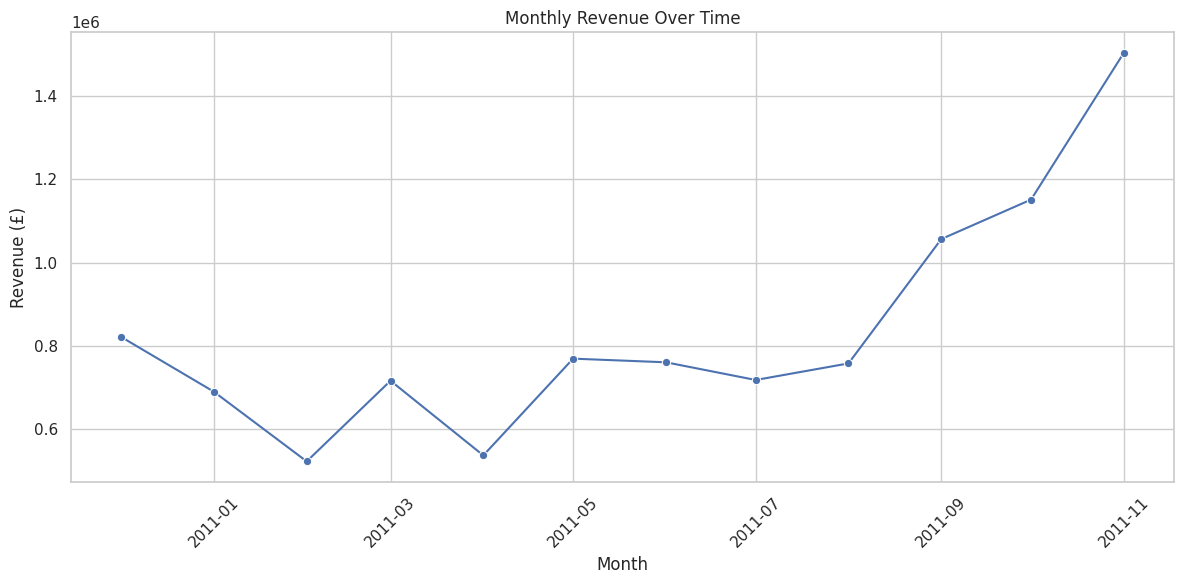

In [108]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=complete_months,
    x="Month",
    y="MonthlyRevenue",
    marker="o"
)

plt.title("Monthly Revenue Over Time")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    IMAGES_DIR / "monthly_revenue.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [109]:
best_month = complete_months.loc[complete_months["MonthlyRevenue"].idxmax()]
worst_month = complete_months.loc[complete_months["MonthlyRevenue"].idxmin()]

print(f"Best month: {best_month['Month'].strftime('%B %Y')} with revenue £{best_month['MonthlyRevenue']:,.2f}")
print(f"Worst month: {worst_month['Month'].strftime('%B %Y')} with revenue £{worst_month['MonthlyRevenue']:,.2f}")

Best month: November 2011 with revenue £1,503,866.78
Worst month: February 2011 with revenue £522,545.56


In [110]:
complete_months["RevenueGrowthPct"] = (complete_months["MonthlyRevenue"].pct_change().mul(100).round(2))

complete_months

,Month,MonthlyRevenue,Orders,Customers,RevenueGrowthPct
0,2010-12-01,821452.730,1559,885,NaN
1,2011-01-01,689811.610,1086,741,-16.03
2,2011-02-01,522545.560,1100,758,-24.25
3,2011-03-01,716215.260,1454,974,37.06
4,2011-04-01,536968.491,1246,856,-25.03
5,2011-05-01,769296.610,1681,1056,43.27
6,2011-06-01,760547.010,1533,991,-1.14
7,2011-07-01,718076.121,1475,949,-5.58
8,2011-08-01,757841.380,1361,935,5.54
9,2011-09-01,1056435.192,1837,1266,39.40


### Key findings

- Monthly revenue reached its lowest level in February 2011 at £522,545.56.
- Revenue recovered in March and increased considerably during the final months of 2011.
- September, October, and November generated revenue growth of 39.40%, 8.98%, and 30.63%, respectively.
- November 2011 was the strongest complete month, generating £1,503,866.78 in revenue from 2,769 orders.
- The increase in revenue was accompanied by growth in both the number of orders and identified customers.
- This pattern suggests strong seasonal demand before the Christmas period.
- December 2011 was excluded from the comparison because the dataset contains transactions only through December 9.